In [2]:
import pandas as pd

# Load the first dataset (The "Telescope" - high level home data)
df_home = pd.read_csv('smart_home_energy_consumption.csv')

# Load the second dataset (The "Microscope" - detailed appliance data)
df_appliance = pd.read_csv('appliance_usage.csv')

# Display the first few rows of both to make sure they loaded!
# Note: In Jupyter, 'display()' prints nice, clean tables instead of raw text.
print("--- Smart Home Data ---")
display(df_home.head())

print("\n--- Detailed Appliance Usage Data ---")
display(df_appliance.head())

--- Smart Home Data ---


,Home ID,Appliance Type,Energy Consumption (kWh),Time,Date,Outdoor Temperature (°C),Season,Household Size
0,94,Fridge,0.20,21:12,2023-12-02,-1.0,Fall,2
1,435,Oven,0.23,20:11,2023-08-06,31.1,Summer,5
2,466,Dishwasher,0.32,06:39,2023-11-21,21.3,Fall,3
3,496,Heater,3.92,21:56,2023-01-21,-4.2,Winter,1
4,137,Microwave,0.44,04:31,2023-08-26,34.5,Summer,5



--- Detailed Appliance Usage Data ---


,date,appliance,start_time,end_time,mode,kwh_consumed,avg_temp,weather_condition
0,11/4/2025,Air Conditioning,18:00,22:00,Cooling,4.2,29.5,Clear
1,11/4/2025,Washing Machine,10:00,11:00,Eco,0.6,29.5,Clear
2,11/4/2025,Dishwasher,20:00,21:00,Normal,0.9,29.5,Clear
3,11/4/2025,Microwave,8:00,8:15,High,0.3,29.5,Clear
4,11/4/2025,Computer,14:00,18:00,Active Use,0.4,29.5,Clear


In [4]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# We start with the df_home dataset we loaded in Step 1
print(f"Original Data Shape: {df_home.shape} (Rows, Columns)")

# ==========================================
# 1. CLEANING
# ==========================================
# a. Remove missing values (Nulls)
df_clean = df_home.dropna()

# b. Remove exact duplicate rows
df_clean = df_clean.drop_duplicates()

# c. Deal with Outliers 
# (Let's remove any crazy energy spikes that are more than 3 standard deviations away from the average)
mean_energy = df_clean['Energy Consumption (kWh)'].mean()
std_energy = df_clean['Energy Consumption (kWh)'].std()
df_clean = df_clean[df_clean['Energy Consumption (kWh)'] <= (mean_energy + 3 * std_energy)]

print(f"Data Shape after Cleaning: {df_clean.shape} (Rows, Columns)")


# ==========================================
# 2. FORMATTING & FEATURE ENGINEERING
# ==========================================
# a. Format 'Date' properly and extract the Month
df_clean['Date'] = pd.to_datetime(df_clean['Date'])
df_clean['Month'] = df_clean['Date'].dt.month

# b. Format 'Time' properly and extract the Hour
df_clean['Time'] = pd.to_datetime(df_clean['Time'], format='%H:%M')
df_clean['Hour'] = df_clean['Time'].dt.hour


# ==========================================
# 3. TRANSFORMATION
# ==========================================
# a. Encoding Categorical Data (Turning Text into 1s and 0s)
df_transformed = pd.get_dummies(df_clean, columns=['Appliance Type', 'Season'], drop_first=True)

# b. Scaling Numerical Data (Normalizing)
# Temperature ranges from -10 to 40, but Household Size is only 1 to 5. 
# We use MinMaxScaler to shrink all numerical features to a scale between 0 and 1 so they are treated equally.
scaler = MinMaxScaler()
numerical_columns = ['Outdoor Temperature (°C)', 'Household Size', 'Hour', 'Month']

# Apply the scaler just to our numerical inputs
df_transformed[numerical_columns] = scaler.fit_transform(df_transformed[numerical_columns])


# Define our final Inputs (X) and Target Output (y)
# We drop the original Date, Time, and Home ID columns as the model doesn't need them anymore
X = df_transformed.drop(columns=['Energy Consumption (kWh)', 'Date', 'Time', 'Home ID'])
y = df_transformed['Energy Consumption (kWh)']

print("\n✅ Preprocessing Complete! Here is what our final transformed data looks like:")
display(X.head())

Original Data Shape: (100000, 8) (Rows, Columns)
Data Shape after Cleaning: (100000, 8) (Rows, Columns)

✅ Preprocessing Complete! Here is what our final transformed data looks like:


,Outdoor Temperature (°C),Household Size,Month,Hour,Appliance Type_Computer,Appliance Type_Dishwasher,Appliance Type_Fridge,Appliance Type_Heater,Appliance Type_Lights,Appliance Type_Microwave,Appliance Type_Oven,Appliance Type_TV,Appliance Type_Washing Machine,Season_Spring,Season_Summer,Season_Winter
0,0.180,0.25,1.000000,0.913043,False,False,True,False,False,False,False,False,False,False,False,False
1,0.822,1.00,0.636364,0.869565,False,False,False,False,False,False,True,False,False,False,True,False
2,0.626,0.50,0.909091,0.260870,False,True,False,False,False,False,False,False,False,False,False,False
3,0.116,0.00,0.000000,0.913043,False,False,False,True,False,False,False,False,False,False,False,True
4,0.890,1.00,0.636364,0.173913,False,False,False,False,False,True,False,False,False,False,True,False


Generating Exploratory Data Analysis (EDA) Visualizations...



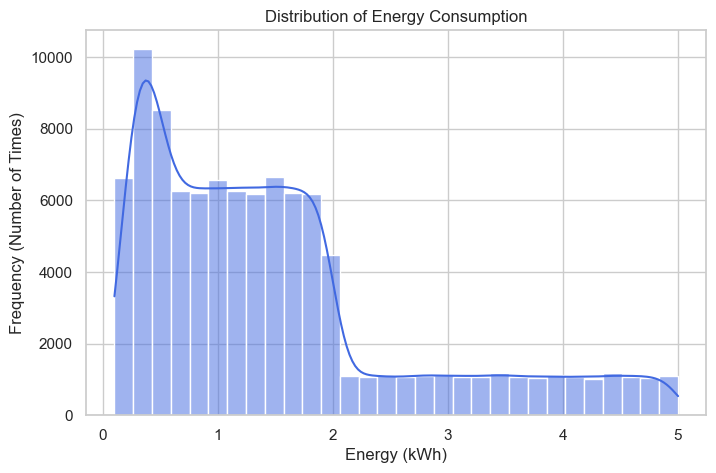

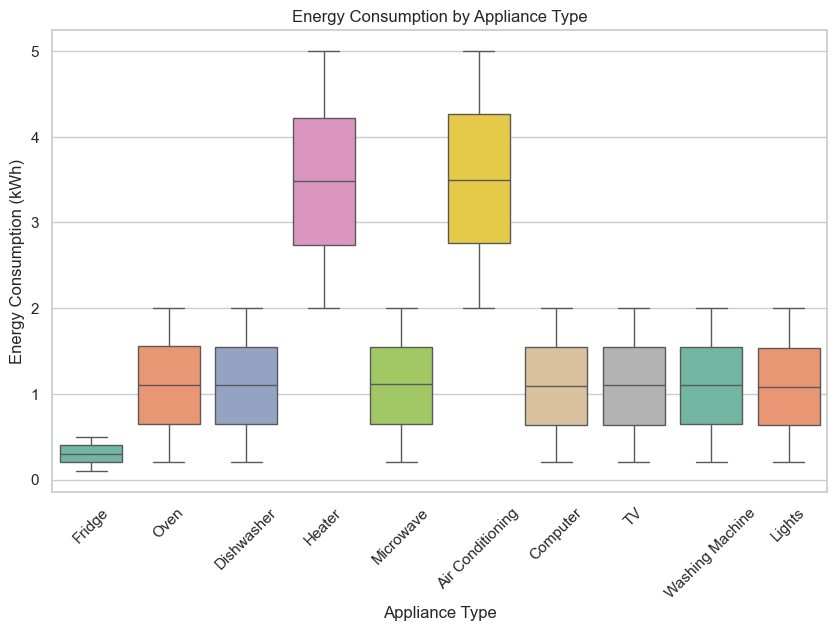

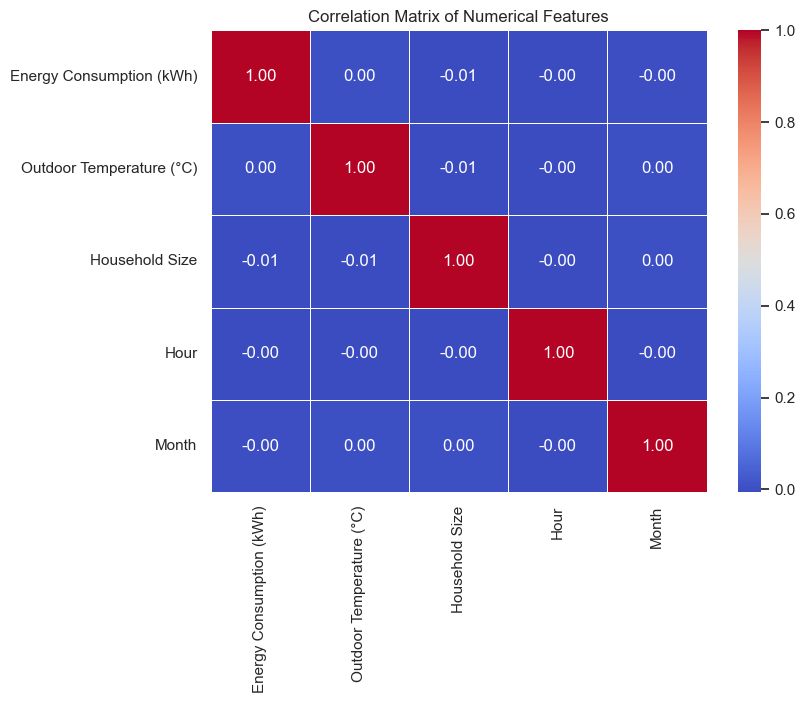

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a nice visual style for our charts
sns.set_theme(style="whitegrid")

print("Generating Exploratory Data Analysis (EDA) Visualizations...\n")

# ==========================================
# Chart 1: The Histogram (Distribution)
# ==========================================
plt.figure(figsize=(8, 5))
sns.histplot(df_clean['Energy Consumption (kWh)'], bins=30, kde=True, color='royalblue')
plt.title('Distribution of Energy Consumption')
plt.xlabel('Energy (kWh)')
plt.ylabel('Frequency (Number of Times)')
plt.show()

# ==========================================
# Chart 2: The Boxplot (Categorical vs Numerical)
# ==========================================
plt.figure(figsize=(10, 6))
sns.boxplot(x='Appliance Type', y='Energy Consumption (kWh)', data=df_clean, hue='Appliance Type', palette='Set2', legend=False)
plt.title('Energy Consumption by Appliance Type')
plt.xticks(rotation=45) # Tilts the text so the appliance names don't overlap
plt.show()

# ==========================================
# Chart 3: The Correlation Heatmap (Finding Relationships)
# ==========================================
# We only want to find mathematical correlations between number columns
numerical_cols = ['Energy Consumption (kWh)', 'Outdoor Temperature (°C)', 'Household Size', 'Hour', 'Month']
corr_matrix = df_clean[numerical_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [8]:
# --- Step 5: Advanced Feature Engineering ---

print("Original columns:", df_clean.columns.tolist())

# 1. Create 'Day_of_Week' and 'Is_Weekend'
# dt.dayofweek returns 0 for Monday and 6 for Sunday
df_clean['Day_of_Week'] = df_clean['Date'].dt.dayofweek

# If the day is 5 (Saturday) or 6 (Sunday), set to 1 (True), else 0 (False)
df_clean['Is_Weekend'] = df_clean['Day_of_Week'].apply(lambda x: 1 if x >= 5 else 0)


# 2. Create 'Part_of_Day' based on the Hour
def get_part_of_day(hour):
    if 5 <= hour <= 11:
        return 'Morning'
    elif 12 <= hour <= 16:
        return 'Afternoon'
    elif 17 <= hour <= 21:
        return 'Evening'
    else:
        return 'Night'

df_clean['Part_of_Day'] = df_clean['Hour'].apply(get_part_of_day)


# Let's look at our newly engineered features!
print("\n✅ Feature Engineering Complete! Look at the new columns on the right:")
display(df_clean[['Date', 'Day_of_Week', 'Is_Weekend', 'Time', 'Hour', 'Part_of_Day', 'Energy Consumption (kWh)']].head(10))

Original columns: ['Home ID', 'Appliance Type', 'Energy Consumption (kWh)', 'Time', 'Date', 'Outdoor Temperature (°C)', 'Season', 'Household Size', 'Month', 'Hour']

✅ Feature Engineering Complete! Look at the new columns on the right:


,Date,Day_of_Week,Is_Weekend,Time,Hour,Part_of_Day,Energy Consumption (kWh)
0,2023-12-02,5,1,1900-01-01 21:12:00,21,Evening,0.20
1,2023-08-06,6,1,1900-01-01 20:11:00,20,Evening,0.23
2,2023-11-21,1,0,1900-01-01 06:39:00,6,Morning,0.32
3,2023-01-21,5,1,1900-01-01 21:56:00,21,Evening,3.92
4,2023-08-26,5,1,1900-01-01 04:31:00,4,Night,0.44
5,2023-05-06,5,1,1900-01-01 11:36:00,11,Morning,4.68
6,2023-06-06,1,0,1900-01-01 12:05:00,12,Afternoon,0.25
7,2023-12-12,1,0,1900-01-01 03:34:00,3,Night,3.50
8,2023-08-16,2,0,1900-01-01 15:22:00,15,Afternoon,0.89
9,2023-09-19,1,0,1900-01-01 16:32:00,16,Afternoon,1.34


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import xgboost as xgb

print("Preparing final data and starting the arena battle...\n")

# ==========================================
# 1. Final Data Prep (Encoding our new features)
# ==========================================
# We define our final features, including our new engineered ones!
features = ['Appliance Type', 'Outdoor Temperature (°C)', 'Season', 
            'Household Size', 'Hour', 'Month', 'Is_Weekend', 'Part_of_Day']

X = df_clean[features]
y = df_clean['Energy Consumption (kWh)']

# Convert all text columns ('Appliance Type', 'Season', 'Part_of_Day') into 1s and 0s
X_encoded = pd.get_dummies(X, drop_first=True)


# ==========================================
# 2. Train / Test Split
# ==========================================
# We hide 20% of the data from the models so we can test them fairly later
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

print(f"Training Data: {X_train.shape[0]} rows")
print(f"Testing Data: {X_test.shape[0]} rows\n")


# ==========================================
# 3. Model 1: Random Forest
# ==========================================
print("Training Random Forest...")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Test Random Forest
rf_predictions = rf_model.predict(X_test)
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_r2 = r2_score(y_test, rf_predictions)


# ==========================================
# 4. Model 2: XGBoost
# ==========================================
print("Training XGBoost...")
xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)

# Test XGBoost
xgb_predictions = xgb_model.predict(X_test)
xgb_mae = mean_absolute_error(y_test, xgb_predictions)
xgb_r2 = r2_score(y_test, xgb_predictions)


# ==========================================
# 5. The Results!
# ==========================================
print("\n🏆 --- THE RESULTS --- 🏆")
print(f"Random Forest  -> MAE: {rf_mae:.4f} kWh | R2 Score: {rf_r2:.4f}")
print(f"XGBoost        -> MAE: {xgb_mae:.4f} kWh | R2 Score: {xgb_r2:.4f}")

if xgb_r2 > rf_r2:
    print("\nWinner: XGBoost! (It captured more patterns in the data)")
else:
    print("\nWinner: Random Forest! (It proved more accurate on this specific dataset)")

Preparing final data and starting the arena battle...

Training Data: 80000 rows
Testing Data: 20000 rows

Training Random Forest...
Training XGBoost...

🏆 --- THE RESULTS --- 🏆
Random Forest  -> MAE: 0.4937 kWh | R2 Score: 0.7305
XGBoost        -> MAE: 0.4822 kWh | R2 Score: 0.7453

Winner: XGBoost! (It captured more patterns in the data)


Evaluating the model's performance visually...

XGBoost Root Mean Squared Error (RMSE): 0.5985 kWh



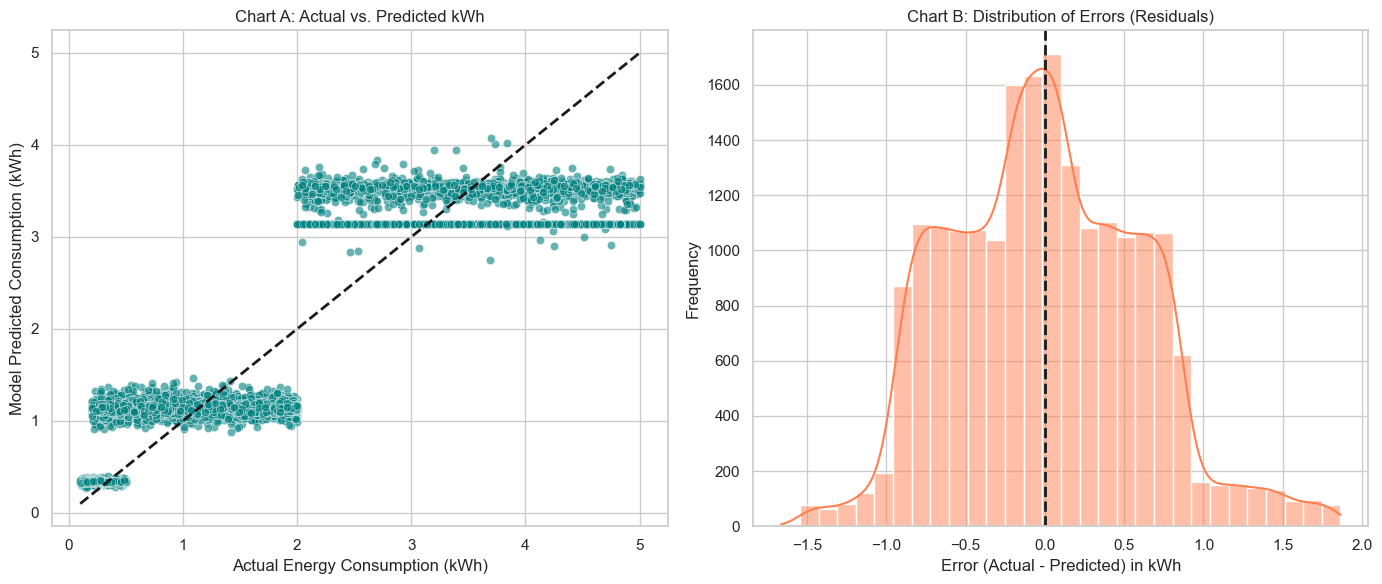

In [12]:
# --- Step 8: Advanced Model Evaluation ---
import numpy as np
from sklearn.metrics import mean_squared_error

print("Evaluating the model's performance visually...\n")

# 1. Calculate one more metric: RMSE (Root Mean Squared Error)
# RMSE punishes the model more for making huge mistakes compared to MAE
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_predictions))
print(f"XGBoost Root Mean Squared Error (RMSE): {xgb_rmse:.4f} kWh\n")

# 2. Calculate the Residuals (The exact error for every single prediction)
# Error = Actual Value - Predicted Value
residuals = y_test - xgb_predictions

# 3. Create the Evaluation Visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.set_theme(style="whitegrid")

# Chart A: Actual vs. Predicted
sns.scatterplot(x=y_test, y=xgb_predictions, ax=axes[0], color='teal', alpha=0.6)
# Draw the "Perfect Prediction" line
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
axes[0].set_title('Chart A: Actual vs. Predicted kWh')
axes[0].set_xlabel('Actual Energy Consumption (kWh)')
axes[0].set_ylabel('Model Predicted Consumption (kWh)')

# Chart B: Distribution of Errors (Residuals)
sns.histplot(residuals, kde=True, ax=axes[1], color='coral', bins=30)
# Draw a line at 0 (Perfect prediction)
axes[1].axvline(x=0, color='k', linestyle='--', lw=2)
axes[1].set_title('Chart B: Distribution of Errors (Residuals)')
axes[1].set_xlabel('Error (Actual - Predicted) in kWh')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [14]:
# --- Step 9: Hyperparameter Tuning (Making the Model Smarter) ---
from sklearn.model_selection import RandomizedSearchCV
import numpy as np
from sklearn.metrics import mean_squared_error

print("Starting the search for the best XGBoost settings... (Please wait, this may take a minute!)\n")

# 1. Define the "dials" (hyperparameters) we want to test
param_grid = {
    'n_estimators': [100, 200, 300],        # Number of trees to build
    'learning_rate': [0.01, 0.05, 0.1],     # How fast the model learns
    'max_depth': [3, 5, 7],                 # How deep/complex each tree can get
    'subsample': [0.8, 1.0]                 # Percentage of data used per tree
}

# 2. Set up the automated tuner
# We use RandomizedSearchCV to test 10 random combinations from our grid above
random_search = RandomizedSearchCV(
    estimator=xgb.XGBRegressor(random_state=42),
    param_distributions=param_grid,
    n_iter=10,                         # Test 10 different combinations
    scoring='neg_mean_absolute_error', # Goal: get the lowest error possible
    cv=3,                              # Cross-validation (tests each setting 3 times for fairness)
    verbose=1,                         # Prints progress updates
    random_state=42
)

# 3. Let it find the best settings using our Training Data!
random_search.fit(X_train, y_train)

# 4. Extract the winning model
best_xgb_model = random_search.best_estimator_

# 5. Test the newly tuned model on our hidden Test Data
tuned_predictions = best_xgb_model.predict(X_test)

# Calculate the new metrics
tuned_mae = mean_absolute_error(y_test, tuned_predictions)
tuned_r2 = r2_score(y_test, tuned_predictions)

print(f"\n✅ Tuning Complete!")
print(f"The Best Settings Found: {random_search.best_params_}")
print(f"--------------------------------------------------")
print(f"Old Default MAE: {xgb_mae:.4f} kWh")
print(f"New Tuned MAE:   {tuned_mae:.4f} kWh")

if tuned_mae < xgb_mae:
    print("\n🎉 Success! The tuned model is more accurate!")
else:
    print("\nInteresting! The default settings were actually perfectly optimized already.")

Starting the search for the best XGBoost settings... (Please wait, this may take a minute!)

Fitting 3 folds for each of 10 candidates, totalling 30 fits

✅ Tuning Complete!
The Best Settings Found: {'subsample': 1.0, 'n_estimators': 100, 'max_depth': 7, 'learning_rate': 0.1}
--------------------------------------------------
Old Default MAE: 0.4822 kWh
New Tuned MAE:   0.4781 kWh

🎉 Success! The tuned model is more accurate!


In [16]:
# --- Step 10: Deployment ---
import joblib
import pandas as pd

print("Deploying the Model...\n")

# 1. Save the model to your hard drive!
model_filename = "smart_home_energy_model.pkl"
joblib.dump(best_xgb_model, model_filename)
print(f"✅ Model successfully saved as '{model_filename}'")


# 2. Simulate a Web App loading the model hours or days later
print("Loading the model into our simulated Web App...\n")
live_app_model = joblib.load(model_filename)

# 3. Create a brand new "Fake Scenario" to test our live app
# Let's say it's a Weekend (1) Evening in the Summer. 
# It's 30 degrees outside, a household of 4, and someone turns on the Air Conditioning.
fake_scenario = pd.DataFrame({
    'Outdoor Temperature (°C)': [30.0],
    'Household Size': [4],
    'Hour': [19],
    'Month': [7],
    'Is_Weekend': [1],
    'Appliance Type_Computer': [0],
    'Appliance Type_Dishwasher': [0],
    'Appliance Type_Fridge': [0],
    'Appliance Type_Heater': [0],
    'Appliance Type_Lights': [0],
    'Appliance Type_Microwave': [0],
    'Appliance Type_Oven': [0],
    'Appliance Type_TV': [0],
    'Appliance Type_Washing Machine': [0],
    'Season_Spring': [0],
    'Season_Summer': [1],
    'Season_Winter': [0],
    'Part_of_Day_Evening': [1],
    'Part_of_Day_Morning': [0],
    'Part_of_Day_Night': [0]
})

# Make sure the columns perfectly match the order of our training data
fake_scenario = fake_scenario.reindex(columns=X_train.columns, fill_value=0)

# 4. Make the live prediction!
predicted_kwh = live_app_model.predict(fake_scenario)

print("📱 --- SMART HOME APP ALERT --- 📱")
print("Scenario: A Household of 4 turned on the Air Conditioning on a hot Summer Weekend evening.")
print(f"AI Prediction: This appliance will use roughly {predicted_kwh[0]:.2f} kWh.")# --- Step 10: Deployment ---
import joblib
import pandas as pd

print("Deploying the Model...\n")

# 1. Save the model to your hard drive!
model_filename = "smart_home_energy_model.pkl"
joblib.dump(best_xgb_model, model_filename)
print(f"✅ Model successfully saved as '{model_filename}'")


# 2. Simulate a Web App loading the model hours or days later
print("Loading the model into our simulated Web App...\n")
live_app_model = joblib.load(model_filename)

# 3. Create a brand new "Fake Scenario" to test our live app
# Let's say it's a Weekend (1) Evening in the Summer. 
# It's 30 degrees outside, a household of 4, and someone turns on the Air Conditioning.
fake_scenario = pd.DataFrame({
    'Outdoor Temperature (°C)': [30.0],
    'Household Size': [4],
    'Hour': [19],
    'Month': [7],
    'Is_Weekend': [1],
    'Appliance Type_Computer': [0],
    'Appliance Type_Dishwasher': [0],
    'Appliance Type_Fridge': [0],
    'Appliance Type_Heater': [0],
    'Appliance Type_Lights': [0],
    'Appliance Type_Microwave': [0],
    'Appliance Type_Oven': [0],
    'Appliance Type_TV': [0],
    'Appliance Type_Washing Machine': [0],
    'Season_Spring': [0],
    'Season_Summer': [1],
    'Season_Winter': [0],
    'Part_of_Day_Evening': [1],
    'Part_of_Day_Morning': [0],
    'Part_of_Day_Night': [0]
})

# Make sure the columns perfectly match the order of our training data
fake_scenario = fake_scenario.reindex(columns=X_train.columns, fill_value=0)

# 4. Make the live prediction!
predicted_kwh = live_app_model.predict(fake_scenario)

print("📱 --- SMART HOME APP ALERT --- 📱")
print("Scenario: A Household of 4 turned on the Air Conditioning on a hot Summer Weekend evening.")
print(f"AI Prediction: This appliance will use roughly {predicted_kwh[0]:.2f} kWh.")

Deploying the Model...

✅ Model successfully saved as 'smart_home_energy_model.pkl'
Loading the model into our simulated Web App...

📱 --- SMART HOME APP ALERT --- 📱
Scenario: A Household of 4 turned on the Air Conditioning on a hot Summer Weekend evening.
AI Prediction: This appliance will use roughly 3.36 kWh.
Deploying the Model...

✅ Model successfully saved as 'smart_home_energy_model.pkl'
Loading the model into our simulated Web App...

📱 --- SMART HOME APP ALERT --- 📱
Scenario: A Household of 4 turned on the Air Conditioning on a hot Summer Weekend evening.
AI Prediction: This appliance will use roughly 3.36 kWh.
